# Traitement d'images: 
## en analyse non supervisée
## en analyse semi-supervisée

In [1]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN

# === Computer Vision ===
import cv2

# === Deep Learning (PyTorch) ===
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC, Precision, Recall, FalsePositives, FalseNegatives

# === NLP / Transformers ===
from transformers import pipeline, AutoTokenizer, AutoModel

import os
import random
import hashlib
from collections import defaultdict

print ("imports terminés")


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


imports terminés


## Analyse Exploratoire des données

In [2]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


exploration visuelle et recheche d'images illisibles

In [3]:
dataset_path = "data/mri_dataset_brain_cancer_oc"

valid_ext = (".jpg", ".jpeg", ".png")

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        if not img_name.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print("Image illisible :", img_path)

verification des dimensions de tout type d'images(avec et sans label)

In [4]:
sizes = []
dataset_path = r"data/mri_dataset_brain_cancer_oc"

valid_extensions = (".jpg", ".jpeg", ".png")

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            print("Image corrompue ou non lisible :", img_path)
            continue
        
        sizes.append(img.shape)

print("Tailles uniques :", set(sizes))

Tailles uniques : {(512, 512, 3)}


Vérification des doublons (par hashing avec chunks)

In [5]:
dataset_path = r"data/mri_dataset_brain_cancer_oc"
valid_ext = (".png", ".jpg", ".jpeg")

hash_dict = defaultdict(list)

def get_hash(filepath):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        path = os.path.join(root, file)

        file_hash = get_hash(path)

        hash_dict[file_hash].append(path)


duplicates = {h: p for h, p in hash_dict.items() if len(p) > 1}

print("Nombre de groupes de doublons :", len(duplicates))

Nombre de groupes de doublons : 0


In [6]:
for h, paths in duplicates.items():
    print("\nDoublon détecté :")
    for p in paths:
        print(p)

Suppression des doublons: 3 cas possibles:
Si un doublon existe entre avec_labels et sans_label: on garde l'image avec_label;
Si les doublons sont dans le même dossier (avec_labels): on garde la première image;
Si les doublons sont dans le même dossier (sans_label): on garde la première image.

In [7]:
deleted = 0

for paths in duplicates.values():

    labeled = [p for p in paths if "avec_labels" in p]
    unlabeled = [p for p in paths if "sans_label" in p]

    # CAS 1 : doublon entre labeled et unlabeled
    if len(labeled) > 0 and len(unlabeled) > 0:

        # garder la première image avec label
        keep = labeled[0]

        # supprimer toutes les unlabeled
        for p in unlabeled:
            os.remove(p)
            deleted += 1
            print("Supprimé (sans label doublon) :", p)

        # si plusieurs labeled, garder la première
        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 2 : uniquement labeled
    elif len(labeled) > 0:

        keep = labeled[0]

        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 3 : uniquement unlabeled
    else:

        keep = unlabeled[0]

        for p in unlabeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon unlabeled) :", p)

print("Total supprimé :", deleted)

Total supprimé : 0


détection d’outliers (images très sombres, très illisibles)

In [8]:
means = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img = cv2.imread(os.path.join(class_path, img_name))

            if img is not None:
                means.append(img.mean())

print("\nStatistiques intensité pixels :")
print("Min :", np.min(means))
print("Max :", np.max(means))
print("Mean :", np.mean(means))


Statistiques intensité pixels :
Min : 14.945938110351562
Max : 136.21646881103516
Mean : 51.60526270688171


Histogramme des intensités (détection d’outliers)

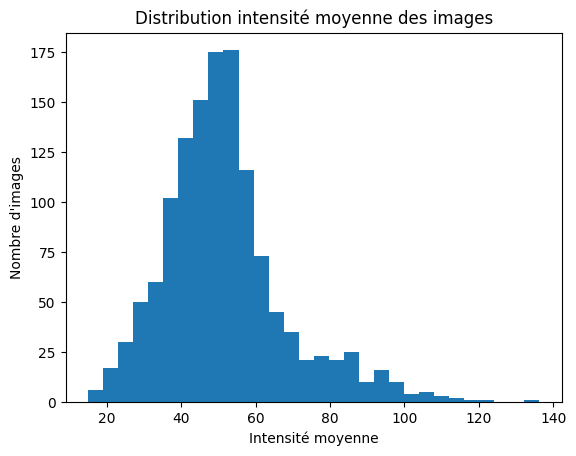

In [9]:
plt.hist(means, bins=30)
plt.title("Distribution intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

choix des outliers: on conserve toutes les images

Explorer les données labelisées (distribution des classes)

In [10]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 49 images


tailles des images sur **données labelisées**

In [11]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:50]:  # on échantillonne
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

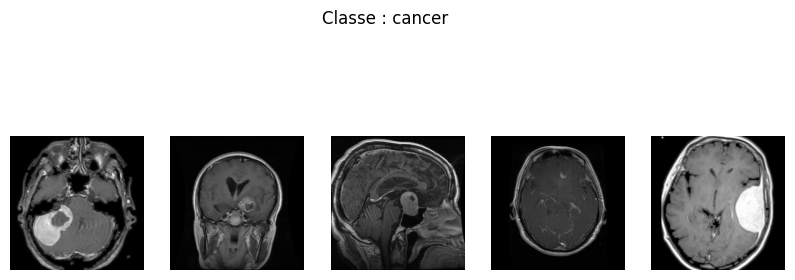

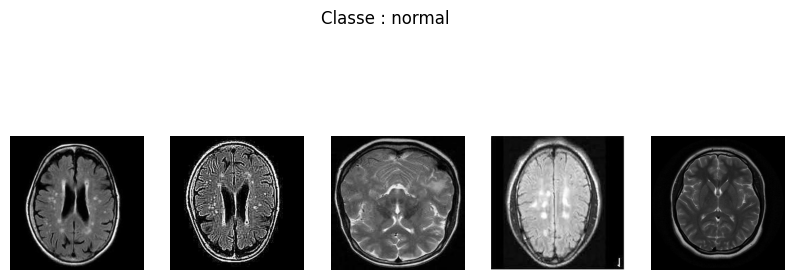

In [12]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

Resize en taille standard : 224x224 (ResNet)

In [13]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y à partir des images labelisées

In [14]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

X = []
y = []

classes = sorted(os.listdir(base_path)) 
print("Classes :", classes)

for label, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        X.append(img)
        y.append(label)

Classes : ['cancer', 'normal']


50 images "cancer" et 4ç images "normal"
X, les images et y, les labels (0,1)

normalisation en [0, 1] des pixels (de 0=noir à 255=blanc) des images (X)

In [15]:
X = np.array(X, dtype="float32") / 255.0   
y = np.array(y)

print(f"Dataset : {X.shape}, Labels : {y.shape}")

Dataset : (99, 224, 224, 3), Labels : (99,)


# analyse non supervisée

on va regarder si les images se partagent bien en 2 groupes (normal devrait etre séparé de cancer)

transformation des images en vecteur

In [16]:
X_features = X.reshape(X.shape[0], -1)

print(X_features.shape)

(99, 150528)


Standardisation des features avant réduction de dimension et clustering

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

Réduction de dimension avec PCA: ici 50 dimensions

In [18]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(99, 50)


Visualisation avec t-SNE en 2D

In [19]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

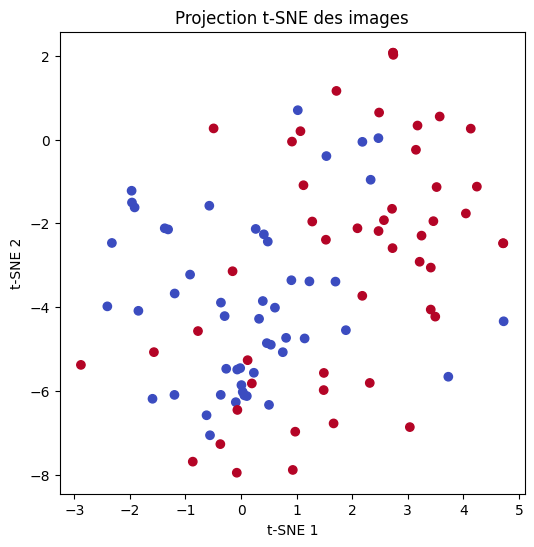

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("Projection t-SNE des images")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

Clustering avec K-Means

In [21]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

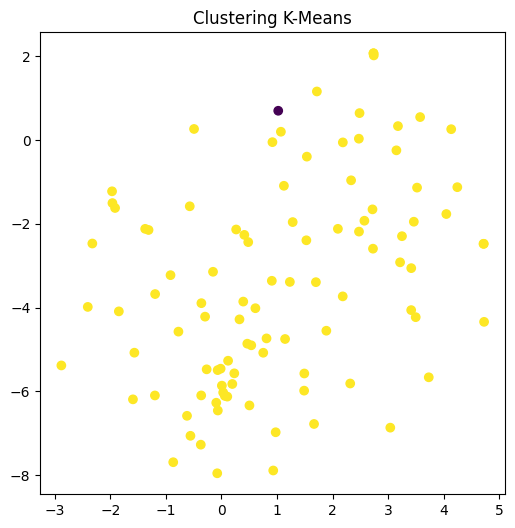

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters, cmap="viridis")
plt.title("Clustering K-Means")
plt.show()

=> 2 groupes totalement très inégaux sur les 100 images =>pertinence très faible

Score ARI (Adjusted Rand Index)
comparaison clusters et labels

In [23]:
ari = adjusted_rand_score(y, clusters)

print("ARI score :", ari)

ARI score : -0.0004042037186742118


=> clustering aléatoire

DBSCAN

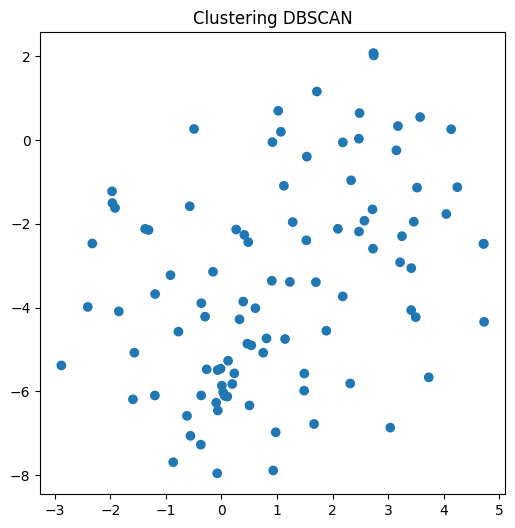

In [24]:
dbscan = DBSCAN(eps=5, min_samples=5)
clusters_db = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap="tab10")
plt.title("Clustering DBSCAN")
plt.show()

=> DBSCAN peu adapté

# analyse semi supervisee:

SPLIT TRAIN_TEST 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (79, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

In [26]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1,activation="sigmoid")
])


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
print(y_train.shape)
print(np.unique(y_train))

(79,)
[0 1]


entraînement

In [30]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5352 - fn: 5.0000 - fp: 28.0000 - loss: 1.4456 - precision: 0.5333 - recall: 0.8649 - roc_auc: 0.5552 - val_accuracy: 0.7500 - val_fn: 2.0000 - val_fp: 0.0000e+00 - val_loss: 0.6215 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5417
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5493 - fn: 16.0000 - fp: 16.0000 - loss: 0.7244 - precision: 0.5676 - recall: 0.5676 - roc_auc: 0.5588 - val_accuracy: 0.2500 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.7326 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 886ms/step - accuracy: 0.5634 - fn: 0.0000e+00 - fp: 31.0000 - loss: 0.6135 - precision: 0.5441 - recall: 1.0000 - roc_auc: 0.8843 - val_accuracy: 0.6250 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.7608 - val_precision: 0.4000 - val_recall: 1.0000 - val_roc_auc: 0.6667
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accu

metriques

# particularité du calcul du f1_sccore non supporté par toutes les versions de Keras:
## calcul manuel entre precision et recall

In [31]:
loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

f1 = 2 * (precision * recall) / (precision + recall + 1e-7)  # 1e-7 pour éviter division par zéro

print(f"Baseline accuracy : {accuracy*100:.2f}%")
print(f"Loss              : {loss:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Faux Positifs     : {int(fp)}")
print(f"Faux Négatifs     : {int(fn)}")

Baseline accuracy : 85.00%
Loss              : 0.5089
ROC AUC           : 0.9100
Precision         : 0.8182
Recall            : 0.9000
F1 Score          : 0.8571
Faux Positifs     : 2
Faux Négatifs     : 1


data augmentation car seulement 99 echantillons avac labels

In [32]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

transfer learning avec ResNet50

In [33]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

2 classes =>obtenir un neurone final

In [34]:
y = np.array(y).astype("float32")

In [35]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5443 - fn: 25.0000 - fp: 11.0000 - loss: 0.8000 - precision: 0.5600 - recall: 0.3590 - roc_auc: 0.5830 - val_accuracy: 0.5000 - val_fn: 0.0000e+00 - val_fp: 10.0000 - val_loss: 0.7379 - val_precision: 0.5000 - val_recall: 1.0000 - val_roc_auc: 0.8250
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 836ms/step - accuracy: 0.5316 - fn: 5.0000 - fp: 32.0000 - loss: 0.8681 - precision: 0.5152 - recall: 0.8718 - roc_auc: 0.5045 - val_accuracy: 0.7000 - val_fn: 6.0000 - val_fp: 0.0000e+00 - val_loss: 0.6182 - val_precision: 1.0000 - val_recall: 0.4000 - val_roc_auc: 0.8100
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 837ms/step - accuracy: 0.6709 - fn: 26.0000 - fp: 0.0000e+00 - loss: 0.6300 - precision: 1.0000 - recall: 0.3333 - roc_auc: 0.7683 - val_accuracy: 0.7500 - val_fn: 5.0000 - val_fp: 0.0000e+00 - val_loss: 0.5754 - val_precision: 1.0000 - val_recall: 0.5000 - val_roc_auc: 0.8000
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 841ms/step

predictions sur images sans label

In [36]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"

X_unlabeled = []

for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X_unlabeled.append(img)

X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0

print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1311, 224, 224, 3)


modele semi supervise

In [37]:
THRESHOLD = 0.9
pseudo_probs = model.predict(X_unlabeled)

41/41 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step


On garde seulement les prédictions très confiantes

# on aplatit y_pseudo avant la concaténation

In [41]:
mask = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))

X_pseudo = X_unlabeled[mask.flatten()]
y_pseudo = (pseudo_probs[mask.flatten()] > 0.5).astype(int).flatten()

print(f"Pseudo labels retenus : {len(y_pseudo)}")
print(f"Distribution : {np.unique(y_pseudo, return_counts=True)}")

Pseudo labels retenus : 24
Distribution : (array([1]), array([24]))


In [42]:
print("y_train shape:", y_train.shape)
print("y_pseudo shape:", y_pseudo.shape)

y_train shape: (79,)
y_pseudo shape: (24,)


In [43]:
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

print(X_combined.shape)
print(y_combined.shape)

(103, 224, 224, 3)
(103,)


entrainement à nouveau

In [44]:
history_ssl = model.fit(
    X_combined, y_combined,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=8
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 644ms/step - accuracy: 0.8252 - fn: 9.0000 - fp: 9.0000 - loss: 0.3828 - precision: 0.8571 - recall: 0.8571 - roc_auc: 0.9143 - val_accuracy: 0.7000 - val_fn: 4.0000 - val_fp: 2.0000 - val_loss: 0.5085 - val_precision: 0.7500 - val_recall: 0.6000 - val_roc_auc: 0.8300
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 583ms/step - accuracy: 0.8350 - fn: 13.0000 - fp: 4.0000 - loss: 0.3698 - precision: 0.9259 - recall: 0.7937 - roc_auc: 0.8960 - val_accuracy: 0.7000 - val_fn: 4.0000 - val_fp: 2.0000 - val_loss: 0.5069 - val_precision: 0.7500 - val_recall: 0.6000 - val_roc_auc: 0.8300
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 644ms/step - accuracy: 0.8350 - fn: 10.0000 - fp: 7.0000 - loss: 0.3478 - precision: 0.8833 - recall: 0.8413 - roc_auc: 0.9149 - val_accuracy: 0.7000 - val_fn: 4.0000 - val_fp: 2.0000 - val_loss: 0.5096 - val_precision: 0.7500 - val_recall: 0.6000 - val_roc_auc: 0.8250
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 687ms/step - accuracy: 0.88

In [45]:
print("Nombre pseudo-labels retenus :", len(X_pseudo))

Nombre pseudo-labels retenus : 24


unlabeled restant = ceux non retenus comme pseudo-labels

In [46]:
X_unlabeled_restant = X_unlabeled[~mask.flatten()]  # ce qui reste après le premier pseudo-labeling
print("Unlabeled restant :", X_unlabeled_restant.shape)

Unlabeled restant : (1287, 224, 224, 3)


entrainemet successif

In [47]:
def semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):

    X_labeled = X_train.copy()
    y_labeled = y_train.copy()

    for i in range(iterations):

        print(f"\n===== Iteration {i+1} =====")

        # prédictions sur données non labelisées
        preds = model.predict(X_unlabeled)

        # sélection forte confiance
        high_conf_mask = (preds > confidence_threshold) | (preds < (1 - confidence_threshold))

        X_pseudo = X_unlabeled[high_conf_mask.flatten()]
        y_pseudo = (preds[high_conf_mask] > 0.5).astype(int).flatten()

        print(f"Pseudo labels retenus : {len(y_pseudo)}")

        if len(y_pseudo) == 0:
            print("Aucun pseudo label fiable, arrêt.")
            break

        # ajout au dataset
        X_labeled = np.concatenate([X_labeled, X_pseudo])
        y_labeled = np.concatenate([y_labeled, y_pseudo])

        # retirer ces images du pool non labelisé
        X_unlabeled = X_unlabeled[~high_conf_mask.flatten()]

        print(f"Dataset train actuel : {X_labeled.shape}")

        # réentrainement
        model.fit(
            X_labeled,
            y_labeled,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        # évaluations succesives
        loss, acc, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

        print(f"Loss      : {loss:.4f}")
        print(f"Accuracy  : {acc:.4f}")
        print(f"ROC AUC   : {roc_auc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"Faux Positifs : {int(fp)}")
        print(f"Faux Négatifs : {int(fn)}")
                
    return model

lancement de la fonction:
modele entrainé et élargi (label et pseudo-label) sur X_combined
y_combined considéré comme y_train de départ
X_unlabeled_restant: seulement sur les sans-labels restants (pas encore pseudo-labelisés)

In [48]:
model = semi_supervised_training(
    model=model,                        
    X_train=X_combined,                 
    y_train=y_combined,                 
    X_unlabeled=X_unlabeled_restant,    
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)


===== Iteration 1 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step
Pseudo labels retenus : 68
Dataset train actuel : (171, 224, 224, 3)
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9181 - fn: 9.0000 - fp: 5.0000 - loss: 0.2077 - precision: 0.9606 - recall: 0.9313 - roc_auc: 0.9616
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step - accuracy: 0.9240 - fn: 9.0000 - fp: 4.0000 - loss: 0.1892 - precision: 0.9683 - recall: 0.9313 - roc_auc: 0.9677
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9123 - fn: 10.0000 - fp: 5.0000 - loss: 0.2188 - precision: 0.9603 - recall: 0.9237 - roc_auc: 0.9530
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9474 - fn: 8.0000 - fp: 1.0000 - loss: 0.1973 - precision: 0.9919 - recall: 0.9389 - roc_auc: 0.9574
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 458ms/step - accuracy: 0.9181 - fn: 9.0000 - fp: 5.0000 - loss: 0.2032 - precision: 0.9606 - recall: 0.9313 - roc_auc: 0.9568
Loss      : 0.5558
Accuracy  : 0.7000
R